### Preprocessing all four datets
- Trimming silence
- Modern noise reduction: Spectral gating
- Normalizing

In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import stft, istft


In [2]:
class AudioPreprocessor:
    def __init__(self, sr=16000, trim_db_first=30, trim_db_second=25):
        self.sr = sr
        self.trim_db_first = trim_db_first
        self.trim_db_second = trim_db_second

    # ---------- Trim ----------
    def trim_audio(self, samples, top_db):
        trimmed, _ = librosa.effects.trim(samples, top_db=top_db)
        return trimmed

    # ---------- Spectral-Gating Denoise ----------
    def spectral_gate_denoise(self, samples, noise_reduction_db=12):
        n_fft = 1024
        hop = 256
        win = "hann"

        _, _, Zxx = stft(samples, fs=self.sr, nperseg=n_fft,
                         noverlap=n_fft - hop, window=win)

        mag = np.abs(Zxx)
        phase = np.angle(Zxx)

        noise_floor = np.percentile(mag, 10, axis=1, keepdims=True)
        reduction_factor = 10 ** (-noise_reduction_db / 20)
        mask = mag > (noise_floor * reduction_factor)
        mag_denoised = mag * mask

        Zxx_denoised = mag_denoised * np.exp(1j * phase)

        _, cleaned = istft(Zxx_denoised, fs=self.sr, nperseg=n_fft,
                           noverlap=n_fft - hop, window=win)

        return cleaned.astype(np.float32)

    # ---------- Waveform CMVN ----------
    def cmvn(self, samples):
        mean = np.mean(samples)
        std = np.std(samples) + 1e-8
        return (samples - mean) / std

    # ---------- Normalize waveform peak ----------
    def normalize(self, samples):
        max_amp = np.max(np.abs(samples))
        return samples / max_amp if max_amp > 0 else samples

    # ---------- Full pipeline ----------
    def process_file(self, file_path):
        samples, _ = librosa.load(file_path, sr=self.sr)

        samples = self.trim_audio(samples, self.trim_db_first)
        samples = self.spectral_gate_denoise(samples)
        samples = self.trim_audio(samples, self.trim_db_second)
        samples = self.cmvn(samples)       
        samples = self.normalize(samples)

        return samples

    # ---------- Batch process + return new dataframe ----------
    def process_and_save(self, df, output_path,
                         path_column="path", actor_column="actor"):

        processed_rows = []

        for _, row in df.iterrows():
            input_path = os.path.normpath(row[path_column])
            actor = int(row[actor_column])
            filename = os.path.basename(input_path)

            out_folder = os.path.join(output_path, f"Actor_{actor:02d}")
            os.makedirs(out_folder, exist_ok=True)

            out_file = os.path.join(out_folder, filename)

            try:
                processed = self.process_file(input_path)
                sf.write(out_file, processed, self.sr)

                new_row = row.copy()
                new_row[path_column] = out_file
                new_row["length_sec"] = len(processed) / self.sr
                processed_rows.append(new_row)
            except Exception as e:
                print(f"Failed processing {input_path}: {e}")

        return pd.DataFrame(processed_rows)

    # ---------- Verify ----------
    def verify_saved_data(self, output_path):
        total = 0
        for folder in sorted(os.listdir(output_path)):
            fp = os.path.join(output_path, folder)
            if os.path.isdir(fp):
                wavs = [f for f in os.listdir(fp) if f.endswith(".wav")]
                print(f"{folder}: {len(wavs)} files")
                total += len(wavs)
        print(f"\nTotal processed files: {total}")

In [3]:
combined_df = pd.read_csv("DataFrame/combined_df.csv")

processor = AudioPreprocessor()
processed_df = processor.process_and_save(combined_df, "Data\Processed_Audio")

processed_df.to_csv("DataFrame/processed_df.csv", index=False)
processor.verify_saved_data("Data/Processed_Audio")

<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
C:\Users\helen\AppData\Local\Temp\ipykernel_12652\4292765245.py:4: SyntaxWarning: invalid escape sequence '\P'
  processed_df = processor.process_and_save(combined_df, "Data\Processed_Audio")


Actor_01: 104 files
Actor_02: 104 files
Actor_03: 104 files
Actor_04: 104 files
Actor_05: 104 files
Actor_06: 104 files
Actor_07: 104 files
Actor_08: 104 files
Actor_09: 104 files
Actor_10: 104 files
Actor_100: 82 files
Actor_101: 82 files
Actor_102: 82 files
Actor_103: 82 files
Actor_104: 82 files
Actor_105: 82 files
Actor_106: 81 files
Actor_107: 82 files
Actor_108: 82 files
Actor_109: 82 files
Actor_11: 104 files
Actor_110: 82 files
Actor_111: 82 files
Actor_112: 82 files
Actor_113: 82 files
Actor_114: 82 files
Actor_115: 82 files
Actor_116: 82 files
Actor_117: 82 files
Actor_118: 82 files
Actor_119: 82 files
Actor_12: 104 files
Actor_120: 82 files
Actor_121: 82 files
Actor_13: 104 files
Actor_14: 104 files
Actor_15: 104 files
Actor_16: 104 files
Actor_17: 104 files
Actor_18: 60 files
Actor_19: 104 files
Actor_20: 104 files
Actor_21: 104 files
Actor_22: 104 files
Actor_23: 104 files
Actor_24: 104 files
Actor_25: 1400 files
Actor_26: 1400 files
Actor_27: 120 files
Actor_28: 120 files

***Before and after denoising***

In [4]:
def compare_before_after(before, after, sr):
    plt.figure(figsize=(14, 10))

    # ---------------- Waveform Before ----------------
    plt.subplot(2, 2, 1)
    librosa.display.waveshow(before, sr=sr)
    plt.title("Waveform (Before Denoising)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # ---------------- Waveform After ----------------
    plt.subplot(2, 2, 2)
    librosa.display.waveshow(after, sr=sr)
    plt.title("Waveform (After Denoising)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # ---------------- Spectrogram Before ----------------
    S_before = librosa.feature.melspectrogram(y=before, sr=sr, n_mels=128)
    S_before_db = librosa.power_to_db(S_before, ref=np.max)

    plt.subplot(2, 2, 3)
    librosa.display.specshow(S_before_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format="%+2.f dB")
    plt.title("Mel Spectrogram (Before)")

    # ---------------- Spectrogram After ----------------
    S_after = librosa.feature.melspectrogram(y=after, sr=sr, n_mels=128)
    S_after_db = librosa.power_to_db(S_after, ref=np.max)

    plt.subplot(2, 2, 4)
    librosa.display.specshow(S_after_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format="%+2.f dB")
    plt.title("Mel Spectrogram (After)")

    plt.tight_layout()
    plt.show()

***Visualization of wavform and spectralgram after processing***

In [6]:
def plot_waveform(samples, sr):
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(samples, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def plot_spectrogram(samples, sr):
    # Convert to Mel-spectrogram
    S = librosa.feature.melspectrogram(y=samples, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format="%+2.f dB")
    plt.title("Mel Spectrogram")
    plt.tight_layout()
    plt.show()

def plot_both(samples, sr):
    plt.figure(figsize=(12, 8))

    # Waveform
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(samples, sr=sr)
    plt.title("Waveform")

    # Spectrogram
    plt.subplot(2, 1, 2)
    S = librosa.feature.melspectrogram(y=samples, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format="%+2.f dB")
    plt.title("Mel Spectrogram")

    plt.tight_layout()
    plt.show()

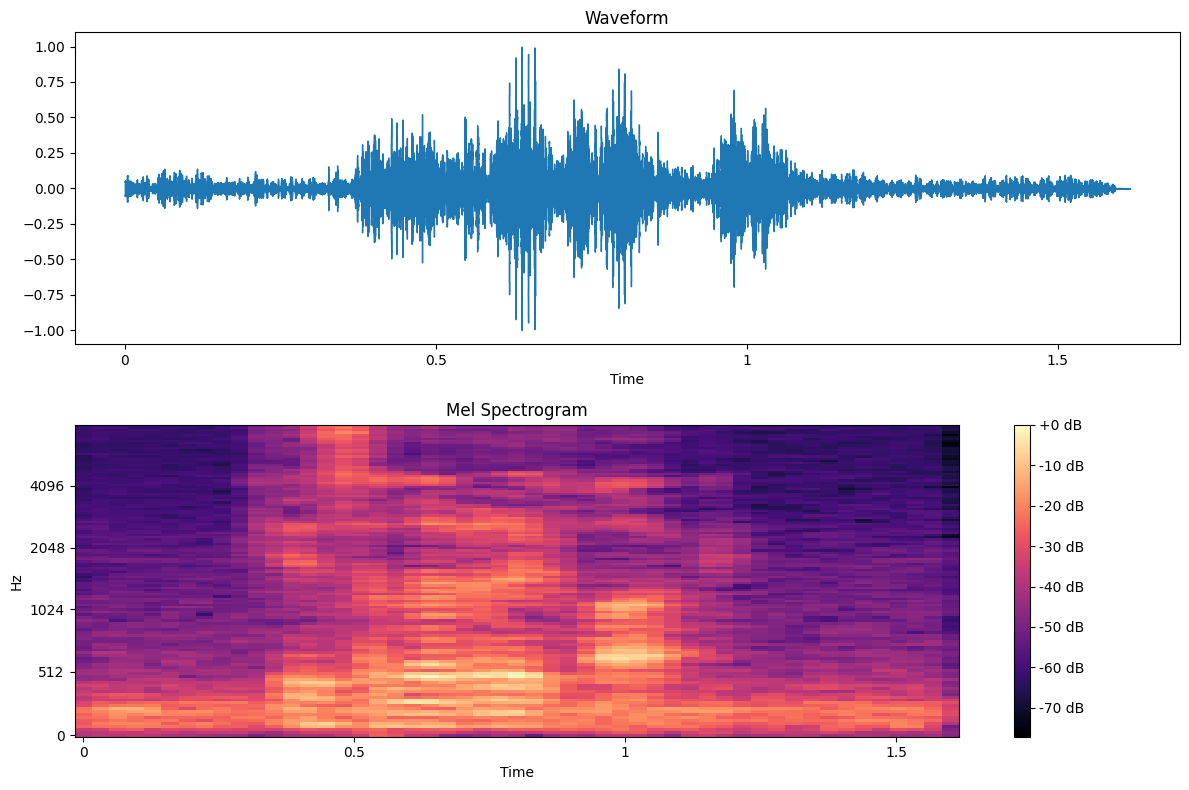

In [8]:
processed_audio = processor.process_file("Data/Dataset/CREMA/Actor_31/03-01-01-01-01-01-31_0019.wav")
plot_both(processed_audio, 16000)